In [163]:
import os
import sys
import torch
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import json

from tqdm import tqdm, trange

In [2]:
sys.path.append('..')

In [3]:
from CRT_utils.CRT.core.dataset import COCODataset, COCODatasetWithID, COCODatasetMixOR, COCODatasetFullMix

In [188]:
dataset = COCODataset(
    '../datasets/COCO18_dset_for_CRT_training/train_metadata.json', 
    '../datasets/COCO18_dset_for_CRT_training/coco18_for_crt', 
    image_size      = (224,224), 
    # _____ ORIGINAL CODE _____
    normalize_means = [0.5, 0.5, 0.5], 
    normalize_stds  = [0.5, 0.5, 0.5],
    # _____ ORIGINAL CODE _____
    
    # _____ MODIFIED VERSION _____
#     normalize_means = [0.5, 0.5, 0.5], 
#     normalize_stds  = [0.5, 5, 0.5]
    # _____ MODIFIED VERSION _____
    
    # _____ ADDED CODE _____
    category_dic_dir = '../datasets/COCO18_dset_for_CRT_training/category_idx_dict.pkl'
    
    # _____ ADDED CODE _____
    
)

reverse_id2id = {value: key for key, value in dataset.id2idx.items()}
id2name = {x['id']: x['name'] for x in dataset.coco_dict['categories']}

-------------------------------
Annotation Counts
-------------------------------
potted plant               8652
tv                         5805
bottle                    24342
chair                     38491
car                       43867
stop sign                  1983
clock                      6334
cup                       20650
fork                       5479
knife                      7770
bowl                      14358
toilet                     4157
laptop                     4970
mouse                      2262
keyboard                   2855
microwave                  1673
oven                       3334
sink                       5610
Total                    202592
-------------------------------



Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


potted plant
target_area/context_area = tensor(0.0567)


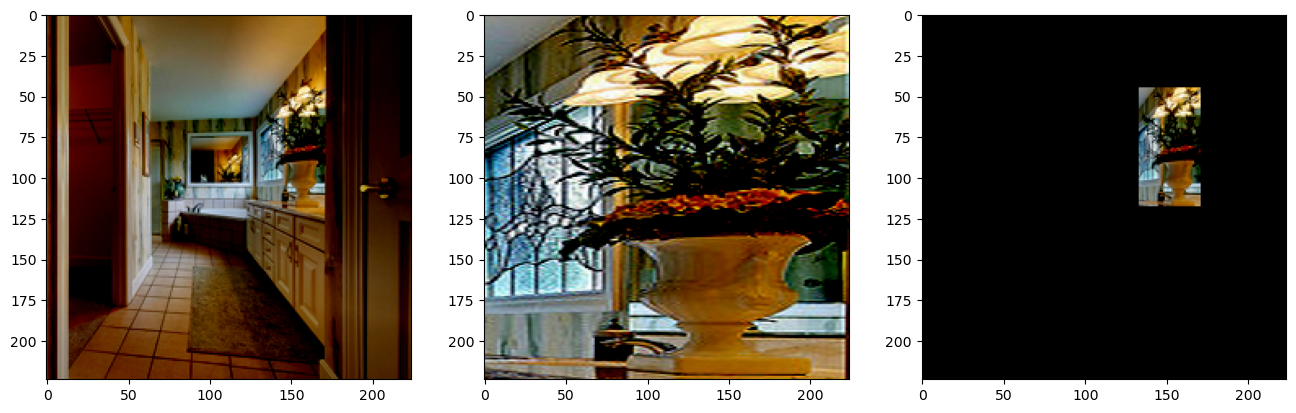

In [189]:
idx = 10

context, target, bbox, category = dataset[idx]

solution = torch.zeros(context.shape[1], context.shape[2])

im_h, im_w = context.shape[1], context.shape[2]
x_min, y_min, w, h = bbox

norm_bbox = int(x_min * im_w), int(y_min * im_h), int(w * im_w), int(h * im_h)

solution[
    norm_bbox[1]:norm_bbox[1]+norm_bbox[3],
    norm_bbox[0]:norm_bbox[0]+norm_bbox[2]
] = 1

fig, ax = plt.subplots(1, 3, figsize=(16, 16))

print(id2name[reverse_id2id[category]])
print('target_area/context_area =', bbox[2]*bbox[3])

ax[0].imshow(context.permute(1,2,0))
ax[1].imshow(target.permute(1,2,0))
ax[2].imshow((context*solution).permute(1,2,0))

In [190]:
bbox

tensor([0.5940, 0.2025, 0.1722, 0.3291])

In [191]:
len(ax)

3

In [192]:
dataset.coco_dict['categories']

[OrderedDict([('id', 3), ('name', 'car')]),
 OrderedDict([('id', 13), ('name', 'stop sign')]),
 OrderedDict([('id', 44), ('name', 'bottle')]),
 OrderedDict([('id', 47), ('name', 'cup')]),
 OrderedDict([('id', 48), ('name', 'fork')]),
 OrderedDict([('id', 49), ('name', 'knife')]),
 OrderedDict([('id', 51), ('name', 'bowl')]),
 OrderedDict([('id', 62), ('name', 'chair')]),
 OrderedDict([('id', 64), ('name', 'potted plant')]),
 OrderedDict([('id', 70), ('name', 'toilet')]),
 OrderedDict([('id', 72), ('name', 'tv')]),
 OrderedDict([('id', 73), ('name', 'laptop')]),
 OrderedDict([('id', 74), ('name', 'mouse')]),
 OrderedDict([('id', 76), ('name', 'keyboard')]),
 OrderedDict([('id', 78), ('name', 'microwave')]),
 OrderedDict([('id', 79), ('name', 'oven')]),
 OrderedDict([('id', 81), ('name', 'sink')]),
 OrderedDict([('id', 85), ('name', 'clock')])]

In [169]:
id2name = {x['id']: x['name'] for x in dataset.coco_dict['categories']}

In [170]:
reverse_id2id = {value: key for key, value in dataset.id2idx.items()}

In [171]:
id2name

{3: 'car',
 13: 'stop sign',
 44: 'bottle',
 47: 'cup',
 48: 'fork',
 49: 'knife',
 51: 'bowl',
 62: 'chair',
 64: 'potted plant',
 70: 'toilet',
 72: 'tv',
 73: 'laptop',
 74: 'mouse',
 76: 'keyboard',
 78: 'microwave',
 79: 'oven',
 81: 'sink',
 85: 'clock'}

In [172]:
dataset.coco_dict.keys()

odict_keys(['info', 'licenses', 'images', 'annotations', 'categories'])

In [173]:
bbox_ls = []

for i in trange(len(dataset)):
    _, _, bbox, _ = dataset[i]
    bbox_ls.append(bbox)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 202592/202592 [16:52<00:00, 200.15it/s]


In [202]:
w_avg, h_avg = 0, 0
area_avg = 0

for bbox in tqdm(bbox_ls):
    w_avg += bbox[2]
    h_avg += bbox[3]
    area_avg += bbox[2] * bbox[3]
    
w_avg /= len(bbox_ls)
h_avg /= len(bbox_ls)
area_avg/= len(bbox_ls)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 202592/202592 [00:01<00:00, 187878.31it/s]


In [175]:
print(w_avg)
print(h_avg)
print(area_avg)

tensor(0.1468)
tensor(0.1662)
tensor(0.0458)


In [194]:
with open('../datasets/COCO18_dset_for_CRT_training/annotations.json') as file:
    metadata = json.load(file)

In [195]:
metadata.keys()

dict_keys(['info', 'licenses', 'images', 'annotations', 'categories'])

In [196]:
len(metadata['images'])

2757

In [197]:
bbox_area_ls = []

for bbox in tqdm(bbox_ls):

    area_avg += bbox[2] * bbox[3]
    
    bbox_area_ls.append(area_avg)
    
bbox_area_np = np.array(bbox_area_ls)



100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 202592/202592 [00:00<00:00, 295155.34it/s]


In [205]:
area_avg -  2 * bbox_area_np.std()

tensor(0.0419)

In [203]:
area_avg

tensor(0.0458)

In [206]:
bbox_area_np.std()

0.001953125